In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('/workdir/jz963/Expression_modeling/Hai_PNAS_dataset/data/data_upstream_4096_downstream_4096.tsv', sep='\t')

In [3]:
data.head()

,gene,species,transcript,median_TPM,gene_family,group_for_cross_validation,Parent,seqid,start,end,strand,upstream_start,upstream_end,downstream_end,downstream_start,seq
0,AT1G01030,Ath,AT1G01030.1,2.487849,210,5,AT1G01030.1,1,11864,12940.0,-,12940,17036.0,7767.0,3671,ATGTATTTCCTAAATAATATAGTAGAATTACACCCCATACCTTCCT...
1,AT1G01040,Ath,AT1G01040.1,13.439130,550,4,AT1G01040.1,1,23519,31079.0,+,19422,23518.0,31079.0,26983,AAGAAGTGGGTCCAAAAATAATATGGGCAGAAACTAGAAAGTATAA...
2,AT1G01050,Ath,AT1G01050.1,100.743800,1181,1,AT1G01050.1,1,31382,32670.0,-,32670,36766.0,27285.0,23189,ATTTTATATTCCTTTGTTTAGGAGTGTCTTTATCTCCTCTTGATTG...
3,AT1G01060,Ath,AT1G01060.7,16.425690,2,3,AT1G01060.7,1,33992,37061.0,-,37061,41157.0,29895.0,25799,ATTGTACACATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATT...
4,AT1G01070,Ath,AT1G01070.1,6.287044,128,5,AT1G01070.1,1,38898,40877.0,-,40877,44973.0,34801.0,30705,CTCCTTTTACCTTCTTACACCAGAAATCACACAAACCCTAGTGTGA...


In [4]:
maxTPM = pd.read_csv('/workdir/jz963/Expression_modeling/Hai_PNAS_dataset/data/data_maxTPM.tsv', sep='\t')
maxTPM.head()

,gene,maxTPM,species
0,AT1G01010,178.218414,Ath
1,AT1G01020,77.563072,Ath
2,AT1G01030,17.956158,Ath
3,AT1G01040,97.261597,Ath
4,AT1G01046,96.711617,Ath


## Merge data and max TPM

In [5]:
merged_df = pd.merge(data, maxTPM, on='gene', how='left')
merged_df.head()

,gene,species_x,transcript,median_TPM,gene_family,group_for_cross_validation,Parent,seqid,start,end,strand,upstream_start,upstream_end,downstream_end,downstream_start,seq,maxTPM,species_y
0,AT1G01030,Ath,AT1G01030.1,2.487849,210,5,AT1G01030.1,1,11864,12940.0,-,12940,17036.0,7767.0,3671,ATGTATTTCCTAAATAATATAGTAGAATTACACCCCATACCTTCCT...,17.956158,Ath
1,AT1G01040,Ath,AT1G01040.1,13.439130,550,4,AT1G01040.1,1,23519,31079.0,+,19422,23518.0,31079.0,26983,AAGAAGTGGGTCCAAAAATAATATGGGCAGAAACTAGAAAGTATAA...,97.261597,Ath
2,AT1G01050,Ath,AT1G01050.1,100.743800,1181,1,AT1G01050.1,1,31382,32670.0,-,32670,36766.0,27285.0,23189,ATTTTATATTCCTTTGTTTAGGAGTGTCTTTATCTCCTCTTGATTG...,294.030640,Ath
3,AT1G01060,Ath,AT1G01060.7,16.425690,2,3,AT1G01060.7,1,33992,37061.0,-,37061,41157.0,29895.0,25799,ATTGTACACATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATT...,806.415039,Ath
4,AT1G01070,Ath,AT1G01070.1,6.287044,128,5,AT1G01070.1,1,38898,40877.0,-,40877,44973.0,34801.0,30705,CTCCTTTTACCTTCTTACACCAGAAATCACACAAACCCTAGTGTGA...,85.810562,Ath


In [6]:
merged_df['log_maxTPM'] = np.log10(merged_df['maxTPM'] + 1)
merged_df.head()

,gene,species_x,transcript,median_TPM,gene_family,group_for_cross_validation,Parent,seqid,start,end,strand,upstream_start,upstream_end,downstream_end,downstream_start,seq,maxTPM,species_y,log_maxTPM
0,AT1G01030,Ath,AT1G01030.1,2.487849,210,5,AT1G01030.1,1,11864,12940.0,-,12940,17036.0,7767.0,3671,ATGTATTTCCTAAATAATATAGTAGAATTACACCCCATACCTTCCT...,17.956158,Ath,1.277750
1,AT1G01040,Ath,AT1G01040.1,13.439130,550,4,AT1G01040.1,1,23519,31079.0,+,19422,23518.0,31079.0,26983,AAGAAGTGGGTCCAAAAATAATATGGGCAGAAACTAGAAAGTATAA...,97.261597,Ath,1.992384
2,AT1G01050,Ath,AT1G01050.1,100.743800,1181,1,AT1G01050.1,1,31382,32670.0,-,32670,36766.0,27285.0,23189,ATTTTATATTCCTTTGTTTAGGAGTGTCTTTATCTCCTCTTGATTG...,294.030640,Ath,2.469867
3,AT1G01060,Ath,AT1G01060.7,16.425690,2,3,AT1G01060.7,1,33992,37061.0,-,37061,41157.0,29895.0,25799,ATTGTACACATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATT...,806.415039,Ath,2.907097
4,AT1G01070,Ath,AT1G01070.1,6.287044,128,5,AT1G01070.1,1,38898,40877.0,-,40877,44973.0,34801.0,30705,CTCCTTTTACCTTCTTACACCAGAAATCACACAAACCCTAGTGTGA...,85.810562,Ath,1.938573


In [7]:
merged_df = merged_df[['gene', 'transcript', 'species_x', 'group_for_cross_validation', 'seq', 'log_maxTPM']]
merged_df.head()

,gene,transcript,species_x,group_for_cross_validation,seq,log_maxTPM
0,AT1G01030,AT1G01030.1,Ath,5,ATGTATTTCCTAAATAATATAGTAGAATTACACCCCATACCTTCCT...,1.277750
1,AT1G01040,AT1G01040.1,Ath,4,AAGAAGTGGGTCCAAAAATAATATGGGCAGAAACTAGAAAGTATAA...,1.992384
2,AT1G01050,AT1G01050.1,Ath,1,ATTTTATATTCCTTTGTTTAGGAGTGTCTTTATCTCCTCTTGATTG...,2.469867
3,AT1G01060,AT1G01060.7,Ath,3,ATTGTACACATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATT...,2.907097
4,AT1G01070,AT1G01070.1,Ath,5,CTCCTTTTACCTTCTTACACCAGAAATCACACAAACCCTAGTGTGA...,1.938573


In [8]:
merged_df = merged_df.rename(columns={
    'gene': 'Gene',
    'transcript': 'Transcript',
    'species_x': 'Species',
    'log_maxTPM': 'Label',
    'seq': 'Seq'
})

In [9]:
merged_df.shape

(589010, 6)

In [10]:
def count_n(seq):
    return seq.count('N')

merged_df = merged_df[merged_df['Seq'].apply(lambda x: count_n(x) <= 82)]
merged_df.shape

(546743, 6)

In [11]:
train = merged_df[(merged_df['Species'] == 'Ath') & (merged_df['group_for_cross_validation'] != 5)]
valid = merged_df[(merged_df['Species'] == 'Ath') & (merged_df['group_for_cross_validation'] == 5)]

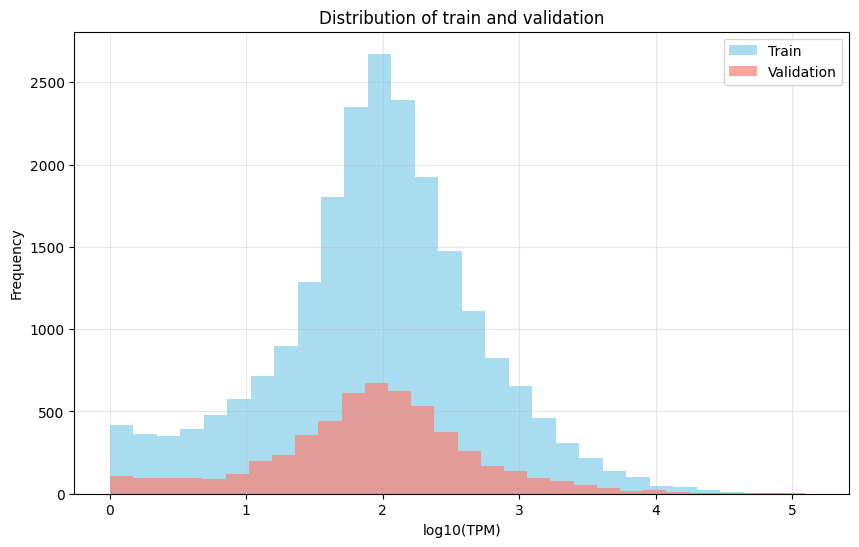

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(train['Label'], bins=30, alpha=0.7, color='skyblue', label='Train')
plt.hist(valid['Label'], bins=30, alpha=0.7, color='salmon', label='Validation')
plt.title('Distribution of train and validation')
plt.xlabel('log10(TPM)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [13]:
train.to_csv('../../results/PlantCAD2_tasks/max_exp_angiosperm/train.tsv', sep='\t', index=False)
valid.to_csv('../../results/PlantCAD2_tasks/max_exp_angiosperm/valid.tsv', sep='\t', index=False)

In [14]:
test = merged_df[merged_df['Species'] != 'Ath']

In [15]:
test.head()

,Gene,Transcript,Species,group_for_cross_validation,Seq,Label
27599,Bradi0012s00201,Bradi0012s00201.1,Bdi,2,GTTGCCGGATCACTCCGGCACAGGGTTGTGACGTTGCCGGGTTCCC...,1.143899
27600,Bradi1g00200,Bradi1g00200.1,Bdi,1,TCACCTCATACAAGCTGACCTTAGCTAAGCTGAGCTGGGAATTTGC...,0.214243
27601,Bradi1g00210,Bradi1g00210.3,Bdi,5,TGCAGAATCATTCCAATACTGTTACAGTTTCAGCTCCAGGTGATTG...,1.348837
27602,Bradi1g00213,Bradi1g00213.1,Bdi,3,AGAACACCAGAACACCAGAACACCAGAACACCAGAACACTAATAGT...,0.041266
27603,Bradi1g00215,Bradi1g00215.1,Bdi,4,GTCTTACTACGCCAACAGATGCCTCTAATGTAGATTAATAGGCCAT...,0.000000


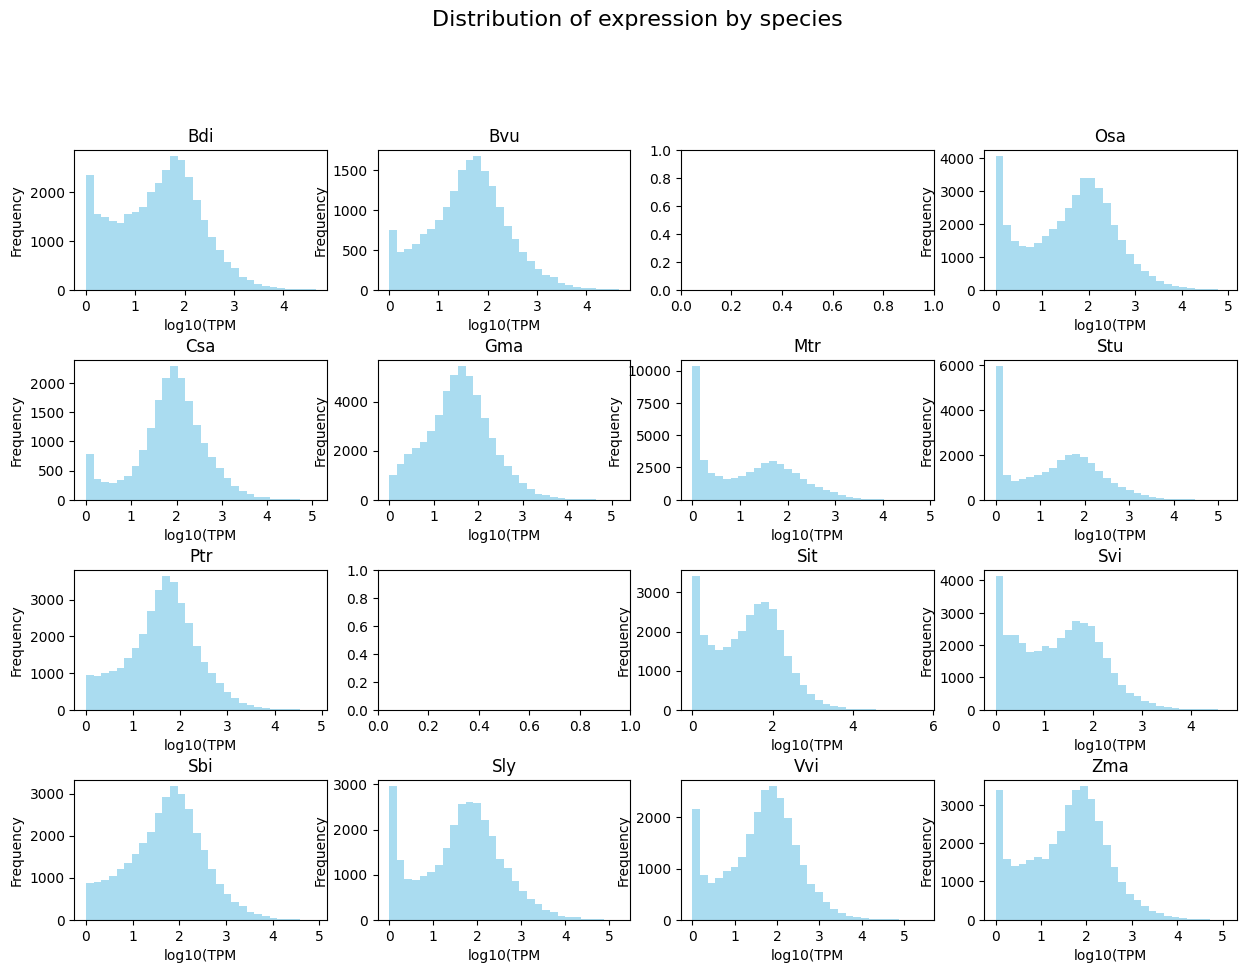

In [16]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5)

for i, species in enumerate(test['Species'].unique()):
    plt.subplot(4, 4, i+1) 
    if species != 'Ppa' and species != 'Cre': # only keep Angiosperms
        curTest = test[test['Species'] == species]
        curTest.to_csv(f'../../results/PlantCAD2_tasks/max_exp_angiosperm/test_{species}.tsv', sep='\t', index=False)
        
        plt.hist(curTest['Label'], bins=30, alpha=0.7, color='skyblue')
        
        # Add title and labels
        plt.title(f'{species}')
        plt.xlabel('log10(TPM')
        plt.ylabel('Frequency')
plt.show()

In [17]:
test['Species'].unique()

array(['Bdi', 'Bvu', 'Cre', 'Osa', 'Csa', 'Gma', 'Mtr', 'Stu', 'Ptr',
       'Ppa', 'Sit', 'Svi', 'Sbi', 'Sly', 'Vvi', 'Zma'], dtype=object)